# B. IHS Specs

**Overview.** Builds the per-vessel technical-specification table that turns AIS activity into emissions. Starting from the IHS ship register, it cleans and imputes the vessel attributes the IMO method needs — beam, draught, length, capacity/size bin, speed, power, engine RPM, engine type, and fuel type — filling gaps with IHS reference fields, single-factor regressions, and median-by-(vessel-class, size-bin). It then derives the correction factors, specific-fuel-consumption (SFC) baselines, and pollutant emission factors per vessel. One row per IMO vessel; these specs are joined onto hourly positions in notebook C.

**Series.** Notebook **B** of the five-part series (A–E) estimating ship emissions in Pacific Island EEZs per the Fourth IMO GHG Study 2020:
- **A. AIS Data Prep** — hourly vessel-position panel tagged with EEZ/coast/port and IHS vessel IDs
- **B. IHS Specs** — per-vessel specs, correction factors, and emission factors *(this notebook)*
- **C. Emissions wIHS** — activity-based emissions for IHS-matched vessels
- **D. Emissions woIHS** — emissions for vessels without an IHS match, via a median-per-type model derived from C
- **E. Emissions Statistics** — monthly country / vessel-type / fishing aggregations and dashboard CSVs

**Method reference.** Fourth IMO GHG Study 2020 (https://www.imo.org/en/ourwork/Environment/Pages/Fourth-IMO-Greenhouse-Gas-Study-2020.aspx). Vessel classes follow the study's `StatCode5` mapping; missing fields are imputed per its guidance. Auxiliary-engine/boiler power factors and some emission tables are pulled from gabrielfuentes.org (tabulations of the Third/Fourth IMO studies).

**Inputs.**
- IHS ship tables via `af.read_ihs_table`: `ShipData.CSV`, `tblCapacities.CSV`, `tblBoilers.CSV` — IHS version set by `ihs_version` (run used `20260202`).
- Auxiliary/boiler power factors: `https://www.gabrielfuentes.org/tables_emissions/ae_ab_power.json` (requires outbound internet).
- Platform S3 root `"s3a://" + os.environ["AWS_WORKING_DIRECTORY_PATH"] + "worldbank/"`.

**Output.** Per-vessel spec/factor table saved as both pickle and parquet:
`…/emissions/Pacific/ihs_emissions_specs {ihs_version}.pkl` and `… .parquet`. Notebook C reads the parquet.

**Requirements.**
- Runs on the **UN Global Platform** — account required: https://datalab.officialstatistics.org
- Uses the platform `ais` library for IHS table access and a Spark session (`spark`) to read the raw CSV tables; the cleaning/regression work is in pandas/numpy with `sklearn.linear_model.LinearRegression`.
- Outbound HTTPS access is needed for the AE/AB power-factor JSON.


20260225 - re-run using 20260202 IHS


previous comment:
NEED TO CHANGE

- include speed correction factor -- applied for run as of June 2025
- emission factor / sfcb  co2 for ethane and LPG? - exclude for now because count is small, less than

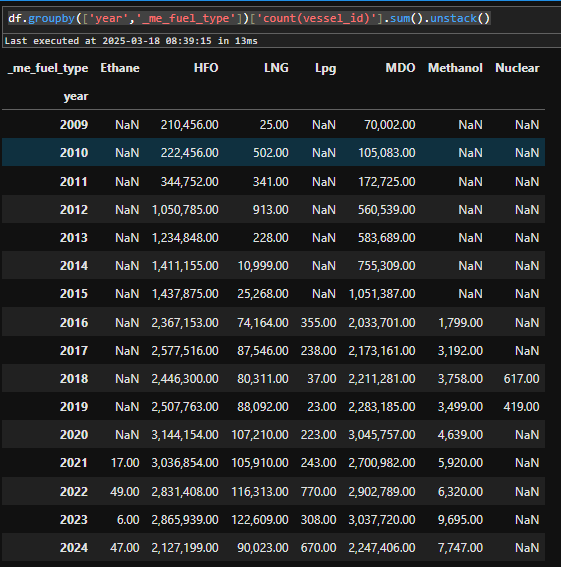

- replacement for speed > 1.5, ffill na lang instead of max speed


# Vessel Specs Preparation for Emissions Calculations

_Section title. The notebook loads IHS ShipData (plus capacities and boilers) into one pandas frame `df` — one row per vessel — then cleans, imputes, and enriches it into the emissions spec table._


In [1]:
import os

In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) #Show all columns in pandas df
pd.set_option('display.max_rows', 100) #Show 100 rows in pandas df
pd.options.display.float_format = '{:,.1f}'.format 

# pd.set_option('future.no_silent_downcasting', True)

from IPython.core.interactiveshell import InteractiveShell #allow multiple outputs in one jupyter cell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
import matplotlib.pyplot as plt

generated new fontManager


In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
# #if using connect, set project path to your local project path
ihs_version = "latest" #20251229

In [6]:
from pyspark.sql import SparkSession
from ais import functions as af

spark = SparkSession.builder.getOrCreate()


In [7]:
wb_path = "s3a://" + os.environ["AWS_WORKING_DIRECTORY_PATH"] + "worldbank/"
project_path = wb_path + "emissions/Pacific/"

# IHS Pre-Processing
https://www.imo.org/en/ourwork/Environment/Pages/Fourth-IMO-Greenhouse-Gas-Study-2020.aspx

https://wwwcdn.imo.org/localresources/en/OurWork/Environment/Documents/Fourth%20IMO%20GHG%20Study%202020%20-%20Full%20report%20and%20annexes.pdf

In [8]:
usecols=[
'LRIMOShipNo',
 'MaritimeMobileServiceIdentityMMSINumber',
 'ShipName',
 'ExName',
 'StatCode5',
 'BreadthExtreme',
 'BreadthMoulded',
 'Draught',
 'LengthOverallLOA',
 'LengthRegistered',
 'LengthBetweenPerpendicularsLBP',
 'Deadweight',
 'GrossTonnage',
 'TEU',
 'Speed',
 'Speedmax',
 'Speedservice',
 'Powerkwservice',
 'Powerkwmax',
 'TotalKilowattsofMainEngines',
 'FuelType1First',
 'FuelType2Second',
 'PropulsionTypeCode',
 'MainEngineRPM',
 'MainEngineModel',
 'MainEngineDesigner',
 'DateOfBuild',
 'MainEngineStrokeType',
 'NumberOfAuxiliaryEngines',
]

df = af.read_ihs_table(spark, "ShipData.CSV", version=ihs_version) \
    .select(*usecols).toPandas()

In [9]:
#Read the latest tblCapacities.CSV
ship_capacity = af.read_ihs_table(spark, "tblCapacities.CSV", version=ihs_version).toPandas().rename(columns={"LRNO":'LRIMOShipNo'})[['LRIMOShipNo','GasCapacity']] \
.set_index("LRIMOShipNo")
ship_capacity.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 270153 entries, 1000019 to 9999993
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   GasCapacity  270153 non-null  int32
dtypes: int32(1)
memory usage: 3.1 MB


In [10]:
#Get information on GasCapacity from tblCapacities and attach to ShipData.
#GasCapacity will be used as basis for size binning of liquid tankers
df['GasCapacity'] = df['LRIMOShipNo'].map(ship_capacity['GasCapacity'])

In [11]:
boiler = af.read_ihs_table(spark, "tblBoilers.CSV", version=ihs_version).toPandas().rename(columns={"LRNO":'LRIMOShipNo'})
boiler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277605 entries, 0 to 277604
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   LRIMOShipNo      277605 non-null  int32 
 1   Sequence         277605 non-null  int32 
 2   BoilerCode       277604 non-null  object
 3   Boiler           277604 non-null  object
 4   NumberOfBoilers  173496 non-null  object
dtypes: int32(2), object(3)
memory usage: 8.5+ MB


In [12]:
boiler['num_boilers'] = pd.to_numeric(boiler['NumberOfBoilers'], errors="coerce")

In [13]:
boiler[boiler['Boiler'].isnull()]['num_boilers'].value_counts()

Series([], Name: num_boilers, dtype: int64)

In [14]:
df['_w_boiler'] = df['LRIMOShipNo'].isin(boiler[boiler['num_boilers']>0]['LRIMOShipNo'])
df['_w_aux'] = df['NumberOfAuxiliaryEngines'] > 0

In [15]:
df._w_boiler.value_counts()

False    263801
True       6352
Name: _w_boiler, dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270153 entries, 0 to 270152
Data columns (total 32 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   LRIMOShipNo                              270153 non-null  int32  
 1   MaritimeMobileServiceIdentityMMSINumber  119073 non-null  float64
 2   ShipName                                 270153 non-null  object 
 3   ExName                                   137187 non-null  object 
 4   StatCode5                                270153 non-null  object 
 5   BreadthExtreme                           270153 non-null  float64
 6   BreadthMoulded                           270153 non-null  float64
 7   Draught                                  270152 non-null  float64
 8   LengthOverallLOA                         270153 non-null  float64
 9   LengthRegistered                         270073 non-null  float64
 10  LengthBetweenPerpendicularsLBP  

# START HERE FOR CALCULATIONS

Importance: Medium

Vessel type, vessel size bin are mainly used as factors to for getting median values of specific fields, as well as correction factors for emissions. 


In [17]:
n = df.shape[0]
n

270153

## Functions Single Factor Regression

_Helper functions: per-vessel-type correlation of a field against candidate predictors, and a per-vessel-type linear regression used to impute missing values._


In [18]:
#Correlation -- Y and factor, by vessel type
def corr_by_vessel_type(df, x_list, y):
    out ={}
    for x in x_list:
        data = df[[y, x,'_vessel_class']].dropna()
        out[x] = data.groupby("_vessel_class").corr().unstack()[(y,x)] * 100
                         
    return pd.DataFrame(out, columns=x_list)


In [19]:
#model per vessel type
def model_and_predict(df_source,dep, ind, basis_col, remark="regression-imo",rsquared = 0.6):
    model_list = {}
    model_score = {}
    
    df = df_source[[dep, f'{dep.lower()}_basis','_vessel_class'] + ind].copy()
    dep_ = df[dep].copy()
    dep_basis = df[basis_col].copy()

    for v in df['_vessel_class'].unique():
        try:

            data  = df[(df['_vessel_class']==v)].dropna(subset=ind + [dep])
            if data.shape[0] > 30:
                X = data[ind].values
                y = data[dep].values
                model = LinearRegression().fit(X, y)
                print(f"{v.ljust(40)}R-squared: {model.score(X,y): .4f}")  
                model_score[v] = model.score(X,y)
            else:
                print(f"{v.ljust(40)}-too small sample to create regression model")
                continue
            
            cond = df[dep].isnull() & (df['_vessel_class']==v)
            data  = df[cond].dropna(subset=ind)
            
            if data.shape[0] == 0:
                print(f"{''.ljust(40)}-no missing data to fill")
                continue
            
            if model_score[v] >= rsquared:
                X = data[ind].values
                y_ = model.predict(X)
                dep_.loc[data.index] = y_
                dep_basis.loc[data.index] = remark
                
                #replace values where estimate is 0 to missing 
                cond = dep_ <= 0
                dep_.loc[cond] = np.nan
                dep_basis.loc[cond] = None
                
                model_list[v] = model
            else:
                print(f"{''.ljust(40)}-Low performance will not use")
            
        except Exception as error:
            print(f"{v}-----error {error}")
    return dep_, dep_basis, model_list, model_score

In [20]:
single_mode = lambda x: x.mode().iloc[0]

# Vessel Type

_Maps each ship's IHS StatCode5 to the Fourth IMO GHG Study vessel class and group number._


In [21]:
def vessel_class_no(df_statcode5):
    """
    ship_type: Pandas dataframe from tblShipTypeCodes.CSV
    return: array of vessel class numbers per 4th IMO GreenHouse Gas Study
    """
    conditions = [
    df_statcode5.str[0].isin(['Y','Z']),   
    df_statcode5.str[:2] == "A2",
    df_statcode5.str[:3] == "A12",
    df_statcode5.str[:3] == "A33",
    df_statcode5.str[:3].isin(["A31","A38","A32"]),
    df_statcode5.str[:3] == "A11",
    df_statcode5.str[:3] == "A13",
    df_statcode5.str[:3] == "A14",
    df_statcode5.str[:4] == "A37B",
    df_statcode5.str[:4] == "A37A",
    df_statcode5.str[:3] == "A36",
    df_statcode5.str[:3] == "A34",
    df_statcode5.str[:4].isin(["A35A","A35C","A35D"]),
    df_statcode5.str[:4] == "A35B",
    df_statcode5.str[:2] == "X1",
    df_statcode5.str[:2] == "B1",
    df_statcode5.str[:3] == "B32",
    df_statcode5.str[:2] == "B2",
    df_statcode5.str[:3].isin(["B31","B33","B34","B35"]),
    df_statcode5.str[0] == "W"
    ]
    
    values = [x for x in range(0,20)]
    
    return np.select(conditions, values, default=100)

#Mapping, Vessel Class No to Vessel Group and Vessel Class
vessel_class_map = {0:['Non-propelled / Non ship structure','Non-Propelled / Non Ship Structure'],
                 1:['Cargo-carrying transport ships','Bulk carrier'],
                 2:['Cargo-carrying transport ships','Chemical tanker'],
                 3:['Cargo-carrying transport ships','Container'],
                 4:['Cargo-carrying transport ships','General cargo'],
                 5:['Cargo-carrying transport ships','Liquified gas tanker'],
                 6:['Cargo-carrying transport ships','Oil tanker'],
                 7:['Cargo-carrying transport ships','Other liquids tanker'],
                 8:['Cargo-carrying transport ships','Ferry-pax only'],
                 9: ['Cargo-carrying transport ships','Cruise'],
                 10: ['Cargo-carrying transport ships', 'Ferry-RoPax'],
                 11: ['Cargo-carrying transport ships','Refrigerated cargo'],
                 12: ['Cargo-carrying transport ships','Ro-Ro'],
                 13: ['Cargo-carrying transport ships','Vehicle'],
                 14: ['Non-merchant ships','Yacht'],
                 15: ['Non-merchant ships','Miscellaneous - fishing'],
                 16: ['Work vessels','Service - tug'],
                 17: ['Work vessels','Offshore'],
                 18: ['Work vessels','Service - other'],
                 19: ['Non-seagoing merchant ships','Miscellaneous - other']
                }

In [22]:
df['_vessel_class_no'] = vessel_class_no(df['StatCode5'])
df[['_vessel_group','_vessel_class']] = pd.DataFrame(df['_vessel_class_no'].map(vessel_class_map).tolist())

In [23]:
#missing is assigned vessel class no 100
df[df['_vessel_class_no']==100][['StatCode5','_vessel_class']].drop_duplicates()

,StatCode5,_vessel_class


In [24]:
df.groupby(['_vessel_group','_vessel_class_no','_vessel_class']).size() / n * 100

_vessel_group                       _vessel_class_no  _vessel_class                     
Cargo-carrying transport ships      1                 Bulk carrier                          9.9
                                    2                 Chemical tanker                       3.5
                                    3                 Container                             4.0
                                    4                 General cargo                        16.5
                                    5                 Liquified gas tanker                  1.5
                                    6                 Oil tanker                            7.5
                                    7                 Other liquids tanker                  0.1
                                    8                 Ferry-pax only                        2.1
                                    9                 Cruise                                0.4
                                    10         

# Beam

Importance: Low

Used as factor for regression models to populate missing values for fields required for emissions calculations

- IMO method: use IHS reference field, and then median per vessel type and size bin to fill missing. 
- Demo notebook: reference field is ```BreadthExtreme```
- WB method: Use ```BreadthExtreme``` as reference field, assuming 0 is null. Estimaate missing using single factor regression model with ind var. ```BreadthMoulded``` from IHS. Leave missing as is

In [25]:
#It is assumed here that a value of 0 beam is impossible. These values are replaced with missing.
temp = pd.concat([df[['_vessel_class']],df[['BreadthExtreme','BreadthMoulded']] == 0], axis=1)
temp = temp.groupby('_vessel_class').sum()
temp['total'] = df.groupby('_vessel_class').size()

for col in ['BreadthExtreme','BreadthMoulded']:
    temp[f'{col}_per_zero'] = temp[col] / temp['total'] * 100
temp[[f'{col}_per_zero' for col in ['BreadthExtreme','BreadthMoulded']]]

,BreadthExtreme_per_zero,BreadthMoulded_per_zero
_vessel_class,,
Bulk carrier,34.0,2.7
Chemical tanker,39.9,1.8
Container,49.9,1.9
Cruise,41.9,3.6
Ferry-RoPax,46.1,4.4
Ferry-pax only,57.1,11.1
General cargo,34.9,10.0
Liquified gas tanker,36.6,1.2
Miscellaneous - fishing,55.8,16.4


In [26]:
#Missing values count
print(f"% of Values missing")
df[['BreadthExtreme','BreadthMoulded']].replace(0,np.nan).isnull().sum() / n * 100

% of Values missing


BreadthExtreme   48.9
BreadthMoulded    9.3
dtype: float64

In [27]:
#Consistently high correlation for BreadthMoulded, varying for width if by vessel class
corr_by_vessel_type(df[['BreadthExtreme','BreadthMoulded','_vessel_class']].replace(0,np.nan), ['BreadthMoulded'], 'BreadthExtreme')

,BreadthMoulded
_vessel_class,
Bulk carrier,100.0
Chemical tanker,100.0
Container,100.0
Cruise,98.7
Ferry-RoPax,98.8
Ferry-pax only,88.6
General cargo,99.8
Liquified gas tanker,100.0
Miscellaneous - fishing,99.7


In [28]:
df['_beam'] = df['BreadthExtreme'].replace(0,np.nan)
df['_beam_basis']=None
df.loc[df['_beam'] > 0, "_beam_basis"] = 'BreadthExtreme'

In [29]:
for replacement in ['BreadthMoulded']:
    print(f"\n{replacement}----")
    df['_beam'],df['_beam_basis'], models, model_scores = \
    model_and_predict(df.replace({replacement:0}, np.nan), '_beam',[replacement], '_beam_basis', remark=f"regression-alt-{replacement}", rsquared=0.6)


BreadthMoulded----
Yacht                                   R-squared:  0.9109
Container                               R-squared:  0.9996
Service - tug                           R-squared:  0.8561
Miscellaneous - other                   R-squared:  0.9817
Service - other                         R-squared:  0.9910
Miscellaneous - fishing                 R-squared:  0.9933
Ferry-pax only                          R-squared:  0.7842
Non-Propelled / Non Ship Structure      R-squared:  0.9799
Chemical tanker                         R-squared:  0.9992
Liquified gas tanker                    R-squared:  1.0000
Oil tanker                              R-squared:  0.9999
Ro-Ro                                   R-squared:  0.9938
Ferry-RoPax                             R-squared:  0.9759
Bulk carrier                            R-squared:  0.9998
Offshore                                R-squared:  0.9898
General cargo                           R-squared:  0.9967
Refrigerated cargo                  

In [30]:
field="beam"
temp = df[['_vessel_class',f'_{field}_basis']].fillna("Missing").pivot_table(index="_vessel_class",columns=f'_{field}_basis', aggfunc="size")
temp["total"] = temp.sum(axis=1)
temp["% Missing"] = temp["Missing"] / temp["total"] * 100
print(f"% Missing per vessel class after filling using alternative fields")
temp.replace(np.nan, "")

% Missing per vessel class after filling using alternative fields


_beam_basis,BreadthExtreme,Missing,regression-alt-BreadthMoulded,total,% Missing
_vessel_class,,,,,
Bulk carrier,"17,578.0",483.0,"8,584.0","26,645.0",1.8
Chemical tanker,"5,740.0",132.0,"3,677.0","9,549.0",1.4
Container,"5,361.0",172.0,"5,165.0","10,698.0",1.6
Cruise,645.0,11.0,454.0,"1,110.0",1.0
Ferry-RoPax,"2,663.0",47.0,"2,235.0","4,945.0",1.0
Ferry-pax only,"2,484.0",107.0,"3,199.0","5,790.0",1.8
General cargo,"29,041.0",989.0,"14,603.0","44,633.0",2.2
Liquified gas tanker,"2,631.0",38.0,"1,484.0","4,153.0",0.9
Miscellaneous - fishing,"24,705.0","1,428.0","29,808.0","55,941.0",2.6


In [31]:
print(f"Distribution beam-basis, total")
df['_beam_basis'].fillna("Missing").value_counts() / n * 100

Distribution beam-basis, total


BreadthExtreme                  51.1
regression-alt-BreadthMoulded   46.4
Missing                          2.5
Name: _beam_basis, dtype: float64

# Draught

Importance: High

Draught (design draught) is a parameter for power consumption. However, it's impact on emissions is low compared to speed. (ratio of instantaneous draught to design draught raise to 2/3)
It is also used as a factor for regression model to estimate missing capacity.

- IMO: use IHS reference field, and then regression model. 
- Demo notebook: reference field is ```Draught```
- WB method: Use ```Draught``` as reference field, assuming 0 is null.

In [32]:
print("% Missing per vessel class") #almost 50% for fishing
(df[df['Draught']==0].groupby('_vessel_class').size() / df.groupby('_vessel_class').size() )*100

% Missing per vessel class


_vessel_class
Bulk carrier                          3.7
Chemical tanker                       3.1
Container                             2.8
Cruise                               10.0
Ferry-RoPax                           9.7
Ferry-pax only                       22.5
General cargo                        11.8
Liquified gas tanker                  3.2
Miscellaneous - fishing              48.9
Miscellaneous - other                22.0
Non-Propelled / Non Ship Structure   27.1
Offshore                              7.9
Oil tanker                           12.1
Other liquids tanker                 12.7
Refrigerated cargo                    5.4
Ro-Ro                                15.3
Service - other                      13.4
Service - tug                        17.4
Vehicle                               2.4
Yacht                                19.3
dtype: float64

In [33]:
cond = df['Draught'].isnull() | (df["Draught"]==0)
df['_draught_basis'] = None
df.loc[~cond,"_draught_basis"] = "Draught"
df['_draught'] = df['Draught'].replace(0,np.nan)

In [34]:
df['_draught_basis'].fillna("missing").value_counts() / n * 100

Draught   80.7
missing   19.3
Name: _draught_basis, dtype: float64

# Length

Importance: Low

Similar with draught, length is also used as a factor for regression models to estimate missing fields. However, it does not directly affect emissions calculations.

The reference field in IHS is ```LengthOverallLOA```. As an improvement, we are using single factor regression models based on IHS ```LengthRegistered```, ```LengthBetweenPerpendicularsLBP```. 

We also assume that a value of 0 is incorrect, and therefore treated as missing. 

In [35]:
#% not missing
df[['LengthOverallLOA','LengthRegistered','LengthBetweenPerpendicularsLBP']].replace(0, np.nan).isnull().sum() / n * 100

LengthOverallLOA                  8.8
LengthRegistered                 72.3
LengthBetweenPerpendicularsLBP   20.2
dtype: float64

In [36]:
#Consistently high corr even if by vessel class
corr_by_vessel_type(df[['LengthOverallLOA','LengthRegistered','LengthBetweenPerpendicularsLBP','_vessel_class']].replace(0,np.nan), 
                    ['LengthRegistered','LengthBetweenPerpendicularsLBP'], 
                    'LengthOverallLOA')

,LengthRegistered,LengthBetweenPerpendicularsLBP
_vessel_class,,
Bulk carrier,99.9,99.8
Chemical tanker,99.9,99.9
Container,99.9,99.7
Cruise,99.6,99.6
Ferry-RoPax,99.7,99.5
Ferry-pax only,98.5,98.8
General cargo,99.8,99.8
Liquified gas tanker,100.0,99.9
Miscellaneous - fishing,99.3,99.4


In [37]:
df['_length'] = df['LengthOverallLOA'].replace(0,np.nan)
df['_length_basis']=None
df.loc[df['_length'] > 0, "_length_basis"] = 'LengthOverallLOA'

In [38]:
for replacement in ['LengthRegistered','LengthBetweenPerpendicularsLBP']:
    print(f"\n{replacement}----")
    df['_length'],df['_length_basis'], models, model_scores = \
    model_and_predict(df.replace({replacement:0}, np.nan), '_length',[replacement], '_length_basis', remark=f"regression-alt0{replacement}", rsquared=0.6)


LengthRegistered----
Yacht                                   R-squared:  0.9899
Container                               R-squared:  0.9989
Service - tug                           R-squared:  0.9614
Miscellaneous - other                   R-squared:  0.9812
Service - other                         R-squared:  0.9913
Miscellaneous - fishing                 R-squared:  0.9866
Ferry-pax only                          R-squared:  0.9710
Non-Propelled / Non Ship Structure      R-squared:  0.9664
Chemical tanker                         R-squared:  0.9988
Liquified gas tanker                    R-squared:  0.9995
                                        -no missing data to fill
Oil tanker                              R-squared:  0.9996
Ro-Ro                                   R-squared:  0.9971
Ferry-RoPax                             R-squared:  0.9945
Bulk carrier                            R-squared:  0.9978
Offshore                                R-squared:  0.9975
General cargo               

In [39]:
field="length"
temp = df[['_vessel_class',f'_{field}_basis']].fillna("Missing").pivot_table(index="_vessel_class",columns=f'_{field}_basis', aggfunc="size")
temp["total"] = temp.sum(axis=1)
temp["% Missing"] = temp["Missing"] / temp["total"] * 100
temp

_length_basis,LengthOverallLOA,Missing,regression-alt0LengthBetweenPerpendicularsLBP,regression-alt0LengthRegistered,total,% Missing
_vessel_class,,,,,,
Bulk carrier,"26,034.0",430.0,83.0,98.0,"26,645.0",1.6
Chemical tanker,"9,315.0",107.0,91.0,36.0,"9,549.0",1.1
Container,"10,520.0",159.0,18.0,1.0,"10,698.0",1.5
Cruise,"1,063.0",11.0,4.0,32.0,"1,110.0",1.0
Ferry-RoPax,"4,777.0",27.0,67.0,74.0,"4,945.0",0.5
Ferry-pax only,"5,290.0",69.0,172.0,259.0,"5,790.0",1.2
General cargo,"41,655.0",654.0,924.0,"1,400.0","44,633.0",1.5
Liquified gas tanker,"4,108.0",35.0,10.0,NaN,"4,153.0",0.8
Miscellaneous - fishing,"45,043.0",726.0,"2,277.0","7,895.0","55,941.0",1.3


In [40]:
#Distribution
df['_length_basis'].fillna("Missing").value_counts() / n * 100

LengthOverallLOA                                91.2
regression-alt0LengthRegistered                  4.5
regression-alt0LengthBetweenPerpendicularsLBP    2.6
Missing                                          1.7
Name: _length_basis, dtype: float64

# Capacities

Importance: Medium

Vessel type, vessel size bin are mainly used as factors to for getting median values of specific fields, as well as correction factors for emissions. 

The size bin is based on capacity which differs according to vessel type

In [41]:
print(f"% Missing")
for col in ['Deadweight','GrossTonnage','TEU','GasCapacity']:
    basis = f'_{col.lower()}_basis'
    capacity = f'_{col.lower()}'
    df[basis] = None
    df[capacity] = df[col].replace(0, np.nan)
    df.loc[~df[capacity].isnull(),basis] = col
    print(f"{col}: {df[capacity].isnull().sum() /n * 100:.2f}%")

% Missing
Deadweight: 28.72%
GrossTonnage: 2.93%
TEU: 92.16%
GasCapacity: 98.39%


# Regression - Beam, Draught, Length, Capacity

From IMO GHG study, missing values on length and capacity can be estimated using regression models with factors beam, draught (p.34)

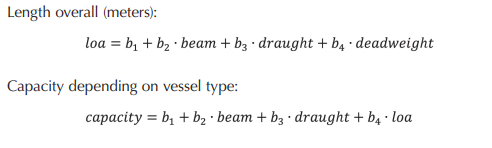

Because there are more known values of length than the capacity, we will create regression model for each capacity with factor length, beam, and draught. 


In [42]:
print(f"% Missing")
df[['_length','_deadweight','_grosstonnage','_teu','_gascapacity','_beam','_draught']].isnull().sum() / n * 100

% Missing


_length          1.7
_deadweight     28.7
_grosstonnage    2.9
_teu            92.2
_gascapacity    98.4
_beam            2.5
_draught        19.3
dtype: float64

In [43]:
for col in ['Deadweight','GrossTonnage','TEU','GasCapacity']:
    basis = f'_{col.lower()}_basis'
    capacity = f'_{col.lower()}'
    print(f"\nRegression Model performance: {capacity}")
    df[capacity],df[basis], models, model_scores = model_and_predict(df, capacity,["_beam","_draught","_length"], basis, rsquared=0.6)


Regression Model performance: _deadweight
Yacht                                   R-squared:  0.7159
Container                               R-squared:  0.9195
                                        -no missing data to fill
Service - tug                           R-squared:  0.1139
                                        -Low performance will not use
Miscellaneous - other                   R-squared:  0.7076
Service - other                         R-squared:  0.3631
                                        -Low performance will not use
Miscellaneous - fishing                 R-squared:  0.4902
                                        -Low performance will not use
Ferry-pax only                          R-squared:  0.5668
                                        -Low performance will not use
Non-Propelled / Non Ship Structure      R-squared:  0.5728
                                        -Low performance will not use
Chemical tanker                         R-squared:  0.9134
Liquified g

In [44]:
#note that we do not need to fill all missing values for each capacity field, only the fields referenced by the vessel type
#for example, for fishing vessels, the capacity does not matter because all is binned to 1 size category
for col in ['Deadweight','GrossTonnage','TEU','GasCapacity']:

    basis = f'_{col.lower()}_basis'
    capacity = f'_{col.lower()}'
    df[basis].fillna("Missing").value_counts()

Deadweight        192559
Missing            73389
regression-imo      4205
Name: _deadweight_basis, dtype: int64

GrossTonnage      262231
Missing             4067
regression-imo      3855
Name: _grosstonnage_basis, dtype: int64

Missing           242447
TEU                21181
regression-imo      6525
Name: _teu_basis, dtype: int64

Missing           259587
regression-imo      6224
GasCapacity         4342
Name: _gascapacity_basis, dtype: int64

# Size


Importance: Medium

Vessel type, vessel size bin are mainly used as factors to for getting median values of specific fields, as well as correction factors for emissions. 

As change from the IMO method, vessels with missing capacity values are binned together (size bin 100) instead of binned with the median size. 

In [45]:
vessel_type_bin_unit = {
     1:'Deadweight',
     2:'Deadweight',
     3:'TEU',
     4:'Deadweight',
     5:'GasCapacity',
     6:'Deadweight',
     7:'Deadweight',
     8:'GrossTonnage',
     9:'GrossTonnage',
     10:'GrossTonnage',
     11:'Deadweight',
     12:'Deadweight',
     13:'GrossTonnage',
     14:'GrossTonnage',
     15:'GrossTonnage',
     16:'GrossTonnage',
     17:'GrossTonnage',
     18:'GrossTonnage',
     19:'GrossTonnage'
    }
vessel_type_bin = {
     1:[0,10000,35000,60000,100000,200000,np.inf],
     2:[0,5000,10000,20000,40000,np.inf],
     3:[0,1000,2000,3000,5000,8000,12000,14500,20000,np.inf],
     4:[0,5000,10000,20000,np.inf],
     5:[0,50000,100000,200000,np.inf],
     6:[0,5000,10000,20000,60000,80000,120000,200000, np.inf],
     7:[0,1000,np.inf],
     8:[0,300,1000,2000,np.inf],
     9:[0,2000,10000,60000,100000,150000,np.inf],
     10:[0,2000,5000,10000,20000,np.inf],
     11:[0,2000,6000,10000,np.inf],
     12:[0,5000,10000,15000,np.inf],
     13:[0,30000,50000,np.inf],
     14:[0,np.inf],
     15:[0,np.inf],
     16:[0,np.inf],
     17:[0,np.inf],
     18:[0,np.inf],
     19:[0,np.inf]
    }
    
def size_bin(df, vessel_type_bin_unit=vessel_type_bin_unit, vessel_type_bin=vessel_type_bin, replace_0 = False):
    x={}
    val={}
    for key in df['_vessel_class_no'].unique():
        cond = df['_vessel_class_no'] == key
        
        if key in vessel_type_bin_unit.keys():
            value = vessel_type_bin_unit[key]
            bins = vessel_type_bin[key]
            labels = [x for x in range(1,len(bins))]
            
            #for vessel types with 1 bin size
            if len(labels) == 1:
                values = df[cond][f"_{value.lower()}"].copy()
                length = df.loc[cond].shape[0]
                x[key] = pd.Series([1]*length, index=df.loc[cond].index)
                
            elif replace_0:
                values = df[cond][f"_{value.lower()}"].copy().replace(0,np.nan)
                x[key] = pd.cut(values, bins=bins, include_lowest=False, right=False, labels=labels)

            else:
                values =  df[cond][f"_{value.lower()}"].copy()
                x[key] = pd.cut(values, bins=bins, include_lowest=False, right=False, labels=labels)

        else:
            length = df.loc[cond].shape[0]
            x[key] = pd.Series([100]*length, index=df.loc[cond].index)
            values =  df[cond][f"_{value.lower()}"].copy()
        
        val[key] = values
    return pd.concat(x).droplevel(level=0).fillna(100), pd.concat(val).droplevel(level=0)

In [46]:
print(f"% Missing Accdng to Capacity Basis per Vessel Type\n")
for key, value in vessel_type_bin_unit.items():
    cond = df['_vessel_class_no'] == key
    print(f"{vessel_class_map[key][1].ljust(25)} {value.rjust(20)}: {(cond & (df[f'_{value.lower()}'].isnull())).sum() / cond.sum() * 100: .2f}%")

% Missing Accdng to Capacity Basis per Vessel Type

Bulk carrier                        Deadweight:  0.30%
Chemical tanker                     Deadweight:  0.16%
Container                                  TEU:  0.62%
General cargo                       Deadweight:  2.84%
Liquified gas tanker               GasCapacity:  0.63%
Oil tanker                          Deadweight:  1.48%
Other liquids tanker                Deadweight:  5.82%
Ferry-pax only                    GrossTonnage:  0.10%
Cruise                            GrossTonnage:  0.00%
Ferry-RoPax                       GrossTonnage:  0.00%
Refrigerated cargo                  Deadweight:  1.24%
Ro-Ro                               Deadweight:  21.21%
Vehicle                           GrossTonnage:  0.00%
Yacht                             GrossTonnage:  15.77%
Miscellaneous - fishing           GrossTonnage:  0.02%
Service - tug                     GrossTonnage:  0.01%
Offshore                          GrossTonnage:  0.22%
Service - o

In [47]:
df['_size_unit'] = df['_vessel_class_no'].map(vessel_type_bin_unit)
df['_size_bin'], df['_capacity'] = size_bin(df, replace_0=True)

In [48]:
#100 means missing size_bin
df['_size_bin'].value_counts()

1.0      181808
2.0       25494
3.0       21470
4.0       17188
100.0      7991
5.0        7177
6.0        4462
8.0        2451
7.0        1834
9.0         278
Name: _size_bin, dtype: int64

In [49]:
#fill missing capacity value with the most common size bin per vessel class
#note that non-propelled / non-ship structure has no size bin in the study
df.groupby('_vessel_class')['_size_bin'].agg(pd.Series.mode)

_vessel_class
Bulk carrier                           4.0
Chemical tanker                        1.0
Container                              2.0
Cruise                                 1.0
Ferry-RoPax                            1.0
Ferry-pax only                         1.0
General cargo                          1.0
Liquified gas tanker                   1.0
Miscellaneous - fishing                1.0
Miscellaneous - other                  1.0
Non-Propelled / Non Ship Structure   100.0
Offshore                               1.0
Oil tanker                             1.0
Other liquids tanker                   1.0
Refrigerated cargo                     2.0
Ro-Ro                                  1.0
Service - other                        1.0
Service - tug                          1.0
Vehicle                                3.0
Yacht                                  1.0
Name: _size_bin, dtype: float64

In [50]:
map_ref = df.groupby('_vessel_class')['_size_bin'].agg(single_mode)
cond = df['_size_bin']==100
df.loc[cond, '_size_bin'] = df.loc[cond, '_vessel_class'].map(map_ref)

df['_size_bin_basis'] = "Capacity"
df.loc[cond, '_size_bin_basis'] = "Mode"

In [51]:
## create index for filling missing values of other fields, filled according to vessel class and size bin
df['_type_size_temp'] = tuple(zip(df['_vessel_class_no'],df['_size_bin']))

In [52]:
df['_size_bin_basis'].value_counts() / n * 100

Capacity   97.0
Mode        3.0
Name: _size_bin_basis, dtype: float64

# Draught -- Fill

_Fills remaining missing design draught with the IMO regression, then the median per vessel class and size bin._


In [53]:
#% Draught that can be filled with imo regression
df[df['_draught'].isnull()  & ~df['_beam'].isnull() & ~df['_capacity'].isnull() & ~df['_length'].isnull()].shape[0] / n * 100

15.986866701461762

In [54]:
col = "_draught"
basis = f'_draught_basis'
print(f"\nRegression Model performance: {col}")
df[col],df[basis], models, model_scores = model_and_predict(df, col,["_beam","_capacity","_length"], basis, rsquared=0.6)


Regression Model performance: _draught
Yacht                                   R-squared:  0.6880
Container                               R-squared:  0.9337
Service - tug                           R-squared:  0.5259
                                        -Low performance will not use
Miscellaneous - other                   R-squared:  0.3565
                                        -Low performance will not use
Service - other                         R-squared:  0.7590
Miscellaneous - fishing                 R-squared:  0.7687
Ferry-pax only                          R-squared:  0.4451
                                        -Low performance will not use
Non-Propelled / Non Ship Structure      R-squared:  0.5783
                                        -Low performance will not use
Chemical tanker                         R-squared:  0.9512
Liquified gas tanker                    R-squared:  0.9292
Oil tanker                              R-squared:  0.9742
Ro-Ro                          

In [55]:
map_ref = df[df['_draught_basis']=="Draught"].groupby(['_vessel_class_no','_size_bin'])['_draught'].agg("median").to_dict()
df['_mapped_temp'] =df["_type_size_temp"].map(map_ref)
cond = df['_draught'].isnull()
df['_draught'] = df['_draught'].fillna(df['_mapped_temp'])
df.loc[cond, '_draught_basis'] = "median"

In [56]:
df['_draught_basis'].fillna("Unknown").value_counts()

Draught           217973
regression-imo     36029
median             16151
Name: _draught_basis, dtype: int64

# Main Engine RPM

Importance: High

Some emission factors are based on the RPM (slow speed, medium speed, or high speed). note the bin of the RPM is important, not the actual value. 

in IMO, it is assumed that RPM, Speed, and Power are related and can be estimated using regression model with additional factors deadweight and length.This will be attempted later

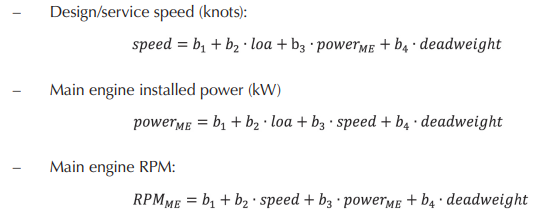

The reference field in IHS is ```MainEngineRPM```

In [57]:
print(f"% Missing")
df['MainEngineRPM'].replace(0, np.nan).isnull().sum() / n * 100

% Missing


35.845243251046625

In [58]:
df['_me_rpm'] = df['MainEngineRPM'].replace(0, np.nan)
df['_me_rpm_basis'] = None
cond = ~df['_me_rpm'].isnull()
df.loc[cond, "_me_rpm_basis"] = "MainEngineRPM"

# Speed

Importance: HIGH - main factor affecting power consumption

There are 3 fields about speed in IHS, 

- ```Speed```- no definition
- ```Speedmax``` - Maximum vessel Speed in knots when the ships engine is running at Maximum continuous rating (MCR).
- ```Speedservice``` - Speed in knots recorded under normal service conditions.

IHS Speed and Speedservice are equal for majority (only 11k not equal because Speedservice is 0)

IMO used IHS Speedmax for speed, based on definition: “Maximum vessel Speed in knots when the ships engine is running at Maximum continuous rating (MCR).”

In [59]:
#more missing with speedmax
print(f"% Missing")
df[['Speed','Speedmax','Speedservice']].replace(0, np.nan).isnull().sum() / n * 100

% Missing


Speed          34.1
Speedmax       81.4
Speedservice   38.9
dtype: float64

In [60]:
#Speed and Speedservice is the same, except for when Speedservice is 0...
df[(df['Speedservice'] != df['Speed'])][['Speedservice','Speed']].describe()

,Speedservice,Speed
count,"12,988.0","12,986.0"
mean,0.0,18.8
std,0.0,9.7
min,0.0,1.0
25%,0.0,11.5
50%,0.0,13.9
75%,0.0,27.0
max,0.0,60.0


In [61]:
#populate missing with single factor regression using Speed
df['_speed'] = df['Speedmax'].replace(0,None)
df['_speed_basis']=None
df.loc[~df['_speed'].isnull(),"_speed_basis"] = "Speedmax"

In [62]:
for replacement in ['Speed','Speedservice']:
    print(f"\n{replacement}----")
    df['_speed'],df['_speed_basis'], models, model_scores = \
    model_and_predict(df.replace({replacement:0}, np.nan), '_speed',[replacement], '_speed_basis', remark=f"regression-alt-{replacement}", rsquared=0.6)


Speed----
Yacht                                   R-squared:  0.8949
Container                               R-squared:  0.8838
Service - tug                           R-squared:  0.7033
Miscellaneous - other                   R-squared:  0.8094
Service - other                         R-squared:  0.9314
Miscellaneous - fishing                 R-squared:  0.8521
Ferry-pax only                          R-squared:  0.9333
Non-Propelled / Non Ship Structure      R-squared:  0.9224
Chemical tanker                         R-squared:  0.6757
Liquified gas tanker                    R-squared:  0.8367
Oil tanker                              R-squared:  0.6949
Ro-Ro                                   R-squared:  0.9465
Ferry-RoPax                             R-squared:  0.9691
Bulk carrier                            R-squared:  0.3614
                                        -Low performance will not use
Offshore                                R-squared:  0.9142
General cargo                     

In [63]:
#Note high missing percentage for fishing
field="speed"
temp = df[['_vessel_class',f'_{field}_basis']].fillna("Missing").pivot_table(index="_vessel_class",columns=f'_{field}_basis', aggfunc="size")
temp["total"] = temp.sum(axis=1)
temp["% Missing"] = temp["Missing"] / temp["total"] * 100
temp

_speed_basis,Missing,Speedmax,regression-alt-Speed,total,% Missing
_vessel_class,,,,,
Bulk carrier,"18,409.0","8,236.0",NaN,"26,645.0",69.1
Chemical tanker,835.0,"3,218.0","5,496.0","9,549.0",8.7
Container,"1,192.0","2,910.0","6,596.0","10,698.0",11.1
Cruise,173.0,316.0,621.0,"1,110.0",15.6
Ferry-RoPax,"1,009.0",914.0,"3,022.0","4,945.0",20.4
Ferry-pax only,"2,116.0",719.0,"2,955.0","5,790.0",36.5
General cargo,"10,778.0","3,846.0","30,009.0","44,633.0",24.1
Liquified gas tanker,175.0,"1,448.0","2,530.0","4,153.0",4.2
Miscellaneous - fishing,"36,444.0",568.0,"18,929.0","55,941.0",65.1


In [64]:
df['_speed_basis'].fillna("missing").value_counts() / n * 100

regression-alt-Speed   41.5
missing                39.9
Speedmax               18.6
Name: _speed_basis, dtype: float64

# Power

Importance: High

Reference field in IHS is ```Powerkwmax``` which is also equivalent to field ```TotalKilowattsofMainEngines```

In [65]:
#When the two fields are not equal, it is because PowerKwmax is 0 while TotalKilowattsofMainEngines is missing
df[df['Powerkwmax'] != df['TotalKilowattsofMainEngines']][['Powerkwmax','TotalKilowattsofMainEngines']].describe()

,Powerkwmax,TotalKilowattsofMainEngines
count,"22,043.0",0.0
mean,0.0,NaN
std,0.0,NaN
min,0.0,NaN
25%,0.0,NaN
50%,0.0,NaN
75%,0.0,NaN
max,0.0,NaN


In [66]:
#Pwerkwservice cannot fill missing powerkwmax
cond = df['Powerkwmax'].replace(0,np.nan).isnull() & ~df['Powerkwservice'].replace(0,np.nan).isnull()
sum(cond)

0

In [67]:
df['_me_power'] = df['Powerkwmax'].replace(0,np.nan)
df['_me_power_basis']=None
df.loc[~df['_me_power'].isnull(),"_me_power_basis"] = "Powerkmax"

In [68]:
field="me_power"
temp = df[['_vessel_class',f'_{field}_basis']].fillna("missing").pivot_table(index="_vessel_class",columns=f'_{field}_basis', aggfunc="size")
temp["total"] = temp.sum(axis=1)
temp["% Missing"] = temp["missing"] / temp["total"] * 100
temp

_me_power_basis,Powerkmax,missing,total,% Missing
_vessel_class,,,,
Bulk carrier,25281,1364,26645,5.1
Chemical tanker,9242,307,9549,3.2
Container,10381,317,10698,3.0
Cruise,1033,77,1110,6.9
Ferry-RoPax,4711,234,4945,4.7
Ferry-pax only,5204,586,5790,10.1
General cargo,40042,4591,44633,10.3
Liquified gas tanker,4039,114,4153,2.7
Miscellaneous - fishing,43071,12870,55941,23.0


# Regression Speed Power RPM

Here we attemp a regression model to estimate speed according to power, length, and deadweight

In [69]:
print(f"% missing")
df[['_speed','_me_power','_me_rpm','_length','_deadweight']].isnull().sum() / n * 100

% missing


_speed        39.9
_me_power     14.3
_me_rpm       35.8
_length        1.7
_deadweight   27.2
dtype: float64

In [70]:
#performance of the regression model is variable...
df['_speed'],df['_speed_basis'], models, model_scores = model_and_predict(df, "_speed",["_length","_me_power","_deadweight"], "_speed_basis", rsquared=0.6)

Yacht                                   R-squared:  0.2336
                                        -Low performance will not use
Container                               R-squared:  0.7926
Service - tug                           R-squared:  0.4311
                                        -Low performance will not use
Miscellaneous - other                   R-squared:  0.1115
                                        -Low performance will not use
Service - other                         R-squared:  0.1579
                                        -Low performance will not use
Miscellaneous - fishing                 R-squared:  0.6566
Ferry-pax only                          R-squared:  0.3555
                                        -Low performance will not use
Non-Propelled / Non Ship Structure      R-squared:  0.1152
                                        -Low performance will not use
Chemical tanker                         R-squared:  0.6421
Liquified gas tanker                    R-squared

In [71]:
df['_me_rpm'],df['_me_rpm_basis'], models, model_scores = model_and_predict(df, "_me_rpm",["_speed","_me_power","_deadweight"], "_me_rpm_basis", rsquared=0.6)

Yacht                                   R-squared:  0.3556
                                        -Low performance will not use
Container                               R-squared:  0.3666
                                        -Low performance will not use
Service - tug                           R-squared:  0.1649
                                        -Low performance will not use
Miscellaneous - other                   R-squared:  0.1409
                                        -Low performance will not use
Service - other                         R-squared:  0.2739
                                        -Low performance will not use
Miscellaneous - fishing                 R-squared:  0.0983
                                        -Low performance will not use
Ferry-pax only                          R-squared:  0.3320
                                        -Low performance will not use
Non-Propelled / Non Ship Structure      R-squared:  0.5801
                                      

# RPM -- Fill

_Fills remaining missing main-engine RPM with the median per vessel class and size bin._


In [72]:
df['_me_rpm_basis'].fillna("Unknown").value_counts() / n  * 100

MainEngineRPM    64.2
Unknown          35.7
regression-imo    0.2
Name: _me_rpm_basis, dtype: float64

In [73]:
cond = ~df['_me_rpm'].isnull()
map_ref = df.loc[cond].groupby(['_vessel_class_no','_size_bin'])['_me_rpm'].agg("median").to_dict()
df['_mapped_temp'] =df["_type_size_temp"].map(map_ref)
df.loc[~cond, "_me_rpm"] = df.loc[~cond]['_mapped_temp']
df.loc[~cond, "_me_rpm_basis"] = "median"

# Speed -- Fill

_Fills remaining missing max speed with the median per vessel class and size bin._


In [74]:
df['_speed_basis'].fillna("Unknown").value_counts() / n * 100

regression-alt-Speed   41.5
Unknown                34.0
Speedmax               18.6
regression-imo          5.9
Name: _speed_basis, dtype: float64

In [75]:
map_ref = df[~df['_speed_basis'].isnull()].groupby(['_vessel_class_no','_size_bin'])['_speed'].agg("median").to_dict()
df['_mapped_temp'] =df["_type_size_temp"].map(map_ref)
cond = df['_speed'].isnull()
df['_speed'] = df['_speed'].fillna(df['_mapped_temp'])
df.loc[cond, '_speed_basis'] = "median"

In [76]:
df['_speed_basis'].fillna("Unknown").value_counts() / n * 100

regression-alt-Speed   41.5
median                 34.0
Speedmax               18.6
regression-imo          5.9
Name: _speed_basis, dtype: float64

# Power --  Fill

_Fills remaining missing main-engine power with the median per vessel class and size bin._


In [77]:
df['_me_power_basis'].fillna("Unknown").value_counts()

Powerkmax    231576
Unknown       38577
Name: _me_power_basis, dtype: int64

In [78]:
map_ref = df[~df['_me_power_basis'].isnull()].groupby(['_vessel_class_no','_size_bin'])['_me_power'].agg("median").to_dict()
df['_mapped_temp'] =df["_type_size_temp"].map(map_ref)
cond = df['_me_power'].isnull()
df['_me_power'] = df['_me_power'].fillna(df['_mapped_temp'])
df.loc[cond, '_me_power_basis'] = "median"

In [79]:
df['_me_power_basis'].fillna("Unknown").value_counts() / n * 100

Powerkmax   85.7
median      14.3
Name: _me_power_basis, dtype: float64

# Main Engine Type and Main Engine Fuel Type

Importance: High

Most emission factors are based on fuel type. In IMO study, missing fuel type is poopulated by getting the most common fuel type per vessel and size, with the assumption that only a small percentage is missing (p.47). However, the amount of missing data does not seem to be low...


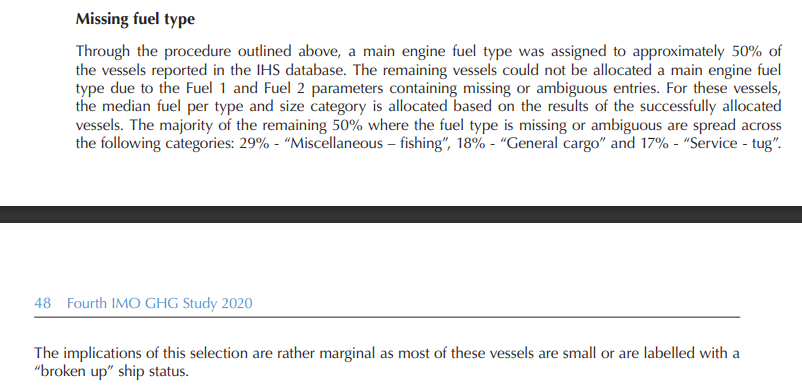

Fuel type for the main engine is based on the fields ```FuelType1First```, ```FuelType2Second```, and ```PropulsionTypeCode```.

Fuel type for the auxiliary engine and boiler is based on the top-down approach (p.48). It is not yet included in this data prep.

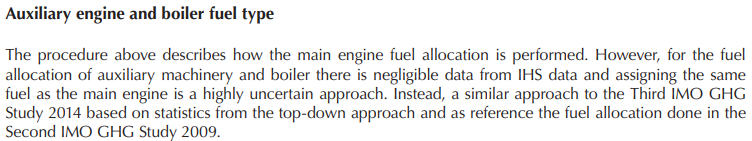

## Fuel Type

_Derives main-engine fuel type (HFO / MDO / LNG / Methanol / …) from the IHS fuel fields._


In [80]:
def me_fuel_type(ship_data):
    methanol = ship_data['FuelType1First'] == "Methanol"
    coal = (ship_data['FuelType1First'] == "Coal") & ship_data['FuelType2Second'].isin(["Not Applicable","Unknown","Yes, But Type Not Known"])
    nuclear = (ship_data['FuelType1First'] == "Nuclear") & ship_data['FuelType2Second'].isin(["Not Applicable","Distillate Fuel", "Unknown","Yes, But Type Not Known"])
    
    lng1 = (ship_data['FuelType1First'] == "Gas Boil Off") & ship_data['FuelType2Second'].isin(["Distillate Fuel","Not Applicable"])
    lng2 = (ship_data['FuelType1First'] == "Lng") & ship_data['FuelType2Second'].isin(["Distillate Fuel","Not Applicable","Unknown","Yes, But Type Not Known","Liquefied Biogas","Lvoc"])
    lng3 = ship_data['FuelType2Second'] == "Gas Boil Off"
    lng4 = ship_data['FuelType1First'].isin(["Not Applicable","Yes, But Type Not Known","Unknown"]) & ship_data['FuelType2Second'].isin(["Lng"])
    
    mdo1 =  (ship_data['FuelType1First'] == "Coal") & (ship_data['FuelType2Second'] == "Distillate Fuel")
    mdo2 =  (ship_data['FuelType1First'] == "Distillate Fuel") & ship_data['FuelType2Second'].isin(["Distillate Fuel","Not Applicable","Unknown", "Yes, But Type Not Known" ])
    mdo3 = ship_data['FuelType1First'].isin(["Distillate Fuel","Not Applicable"]) & (ship_data['FuelType2Second'] == "Distillate Fuel")
    hfo =  ((ship_data['FuelType1First'] == "Residual Fuel") | (ship_data['FuelType2Second'] == "Residual Fuel")) \
            & ~((ship_data['PropulsionTypeCode'].str[0] == "S") & (ship_data['StatCode5'].str[:3] == "A11"))
    lng5 =  ((ship_data['FuelType1First'] == "Residual Fuel") | (ship_data['FuelType2Second'] == "Residual Fuel")) \
              & ((ship_data['PropulsionTypeCode'].str[0] == "S") & (ship_data['StatCode5'].str[:3] == "A11"))
    others = ship_data['FuelType1First'].isin(["Ammonia","Hydrogen","Lpg","Ethane"])
    
    return np.where(methanol, "Methanol",
           np.where(coal, "Coal",
           np.where(nuclear, "Nuclear",
           np.where(lng1 | lng2 | lng3 | lng4 | lng5, "LNG",
           np.where(mdo1 | mdo2 | mdo3, "MDO",
           np.where(hfo, "HFO",
           np.where(others, ship_data['FuelType1First'],None)))))))

In [81]:
df['_me_fuel_type'] = me_fuel_type(df)
df['_me_fuel_type_basis'] = None
df.loc[~df['_me_fuel_type'].isnull(),'_me_fuel_type_basis'] = "imo"

## Main Engine Type

_Derives main-engine type (SSD / MSD / HSD / LNG-Otto / etc.) from propulsion code, RPM bin, and fuel._


In [82]:
def me_type(df):
    oil = df['PropulsionTypeCode'].str[0].isin(["D","A"])
    ssd =  df['_me_rpm'] <= 300
    msd =  df['_me_rpm'].between(300,900, "right")
    hsd =  df['_me_rpm'] > 900
    hsd2 = df['PropulsionTypeCode'].str[0] == "P"
    lng = (df['FuelType1First'] == "Lng") | (df['FuelType2Second'] == "Lng")
    gas_fuel = df['_me_fuel_type'].str.contains("Gas")
    x = df['MainEngineModel'].fillna("")
    otto_ss = x.str.contains("X") | x.str.contains("DF") | x.str.contains("ME-GA")
    diesel = x.str.contains("ME")
    x = df['MainEngineDesigner'].fillna("")
    lbsi = x.str.contains("Rolls") | x.str.contains("Bergen")
    lng_sub =   otto_ss & diesel & lbsi
    methanol_ss = (df['_me_fuel_type'] == "Methanol") & ssd
    methanol_ms = (df['_me_fuel_type'] == "Methanol") & ~ssd
    gas_turbine = df['PropulsionTypeCode'].str[0] == "G"
    steam = df['PropulsionTypeCode'].str[0].isin(["R","S"])
    sail = df['PropulsionTypeCode'].str[0] == "W"
    battery =  df['PropulsionTypeCode'].str[0].isin(["B","H","F"])
    nonprop = df['PropulsionTypeCode'].str[:2] == "NP"
    
    return np.where(nonprop, "Non-Propelled",
           np.where(battery,"Batteries",
           np.where(steam, "Steam Turbine",
           np.where(sail,"Sail",
           np.where(gas_turbine, "Gas Turbine",
           np.where(oil & ssd & gas_fuel, "Gas Turbine",
           np.where(oil & msd & gas_fuel, "Gas Turbine",
           np.where(methanol_ss, "Methanol SS",
           np.where(methanol_ms, "Methanol MS",
           np.where(lng & lbsi, "LBSI",
           np.where(lng & otto_ss, "LNG-Otto SS",
           np.where(lng & diesel, "LNG-Diesel",
           np.where(lng & ~lng_sub, "LNG-Otto MS",
           np.where(oil & ssd, "SSD",
           np.where(oil & msd, "MSD",
           np.where(oil & hsd, "HSD",
           np.where(hsd2, "HSD",
           None)))))))))))))))))

In [83]:
df['_me_type'] = me_type(df)
cond = df['_me_type'].isnull()
print(f"%Missing : {sum(cond)/n*100:.2f}")

%Missing : 0.00


## Fill missing

_Fills missing engine type and fuel type using the most common consistent combination per vessel class and size bin._


In [84]:
#in IMO, missing fields for ME type and fuel type are populated by getting the most common according to vessel type size
#however, this can produce conflicting combination of me type and fuel type. E.g., Oil engines (MSD, HSD, SSD) should not have LNG fuel type
#thus decided to include ME type / fuel type in the factors

In [85]:
print(f"% missing")
df[['_me_type','_me_fuel_type']].isnull().sum()/ n * 100

% missing


_me_type         0.0
_me_fuel_type   54.1
dtype: float64

In [86]:
#fill me type, mode including fuel type
cond = df['_me_type'].isnull()
df["_me_type_basis"] = None
df.loc[~cond, "_me_type_basis"] = "Fuel, Propulsion, Engine"

index_ = df[['_vessel_class_no','_size_bin','_me_fuel_type']].to_records(index=False).tolist()
map_ref = df[~cond & ~df['_me_fuel_type'].isnull()].groupby(['_vessel_class_no','_size_bin','_me_fuel_type'])['_me_type'].agg(single_mode).to_dict()
df['_mapped_temp'] = pd.Series(index_).map(map_ref)
df['_me_type'] = df['_me_type'].fillna(df['_mapped_temp'])
df.loc[cond, '_me_type_basis'] = "mode incl metype"

In [87]:
print(f"% missing")
df[['_me_type','_me_fuel_type']].isnull().sum()/ n * 100

% missing


_me_type         0.0
_me_fuel_type   54.1
dtype: float64

In [88]:
#fill acording to vessel class and size bin only
map_ref = df[df['_me_type_basis']=="Fuel, Propulsion, Engine"].groupby(['_vessel_class_no','_size_bin'])['_me_type'].agg(single_mode
                                                                                                                        ).to_dict()
df['_mapped_temp'] = df['_type_size_temp'].map(map_ref)
df['_me_type'] = df['_me_type'].fillna(df['_mapped_temp'])
cond = df['_me_type'].isnull()
df.loc[cond, '_me_type_basis'] = "mode"

print(f"% missing")
df[['_me_type','_me_fuel_type']].isnull().sum()/ n * 100

% missing


_me_type         0.0
_me_fuel_type   54.1
dtype: float64

In [89]:
#fill me fuel type
df['_me_fuel_type_basis'] = None
cond = df['_me_fuel_type'].isnull()
df.loc[~cond, "_me_fuel_type_basis"] = "Fuel, Propulsion"

index_ = df[['_vessel_class_no','_size_bin','_me_type']].to_records(index=False).tolist()
map_ref = df[(df['_me_type_basis'] == "Fuel, Propulsion, Engine") & (df['_me_fuel_type_basis']=="Fuel, Propulsion")] \
.groupby(['_vessel_class_no','_size_bin','_me_type'])['_me_fuel_type'].agg(single_mode).to_dict()

df['_mapped_temp'] = pd.Series(index_).map(map_ref)
df['_me_fuel_type'] = df['_me_fuel_type'].fillna(df['_mapped_temp'])
cond = ~df['_me_fuel_type'].isnull() & df['_me_fuel_type_basis'].isnull()
df.loc[cond, '_me_fuel_type_basis'] = "mode incl metype"

index_ = df[['_vessel_class_no','_size_bin']].to_records(index=False).tolist()
map_ref = df[(df['_me_type_basis'] == "Fuel, Propulsion, Engine") & (df['_me_fuel_type_basis']=="Fuel, Propulsion")] \
.groupby(['_vessel_class_no','_size_bin'])['_me_fuel_type'].agg(single_mode).to_dict()

df['_mapped_temp'] = pd.Series(index_).map(map_ref)
df['_me_fuel_type'] = df['_me_fuel_type'].fillna(df['_mapped_temp'])
cond = ~df['_me_fuel_type'].isnull() & df['_me_fuel_type_basis'].isnull()
df.loc[cond, '_me_fuel_type_basis'] = "mode"

print(f"% missing")
df[['_me_type','_me_fuel_type']].isnull().sum()/ n * 100

% missing


_me_type        0.0
_me_fuel_type   0.0
dtype: float64

In [90]:
df[df['_me_fuel_type'].isnull()][['_me_type','_vessel_class','_size_bin','_me_fuel_type_basis']].drop_duplicates().sort_values(['_vessel_class','_me_type'])

,_me_type,_vessel_class,_size_bin,_me_fuel_type_basis


In [91]:
df['_me_fuel_type_basis'].fillna("Unknown").value_counts() / n * 100

mode incl metype   54.0
Fuel, Propulsion   45.9
mode                0.1
Name: _me_fuel_type_basis, dtype: float64

# Correction Factors

_Computes the weather, fouling, and speed correction factors applied to power demand._


In [92]:
capacity_bin_size_factor = {
    1:[0,2,np.inf],
    2:[0,3, np.inf],
    3:[0,2, np.inf],
    4:[0,3,np.inf],
    5:[0,1,np.inf],
    6:[0,3,np.inf],
    7:[0,1,np.inf],
    8:[0,100,np.inf],
    9:[0,2,np.inf],
    10:[0,100,np.inf],
    11:[0,1,np.inf],
    12:[0,2,np.inf],
    13:[0,1,np.inf],
    14:[0,1,np.inf],
    15:[0,100,np.inf],
    16:[0,100,np.inf],
    17:[0,100,np.inf],
    18:[0,100,np.inf],
    19:[0,100,np.inf]
}

def correction_factor(df):
    x={}
    for key in df['_vessel_class_no'].unique():
        cond = df['_vessel_class_no'] == key
        if key in vessel_type_bin_unit.keys():
            bins = capacity_bin_size_factor[key]
            x[key] = pd.cut(df.loc[cond, '_size_bin'], bins=bins, right=False, labels=[0.909,0.867])
        
        else:
            length = df.loc[cond].shape[0]
            x[key] = pd.Series([100]*length, index=df.loc[cond].index)
        
    
    return pd.concat(x).droplevel(level=0)

In [93]:
df['_me_power_weather_cf'] = correction_factor(df)
df['_me_power_fouling_cf'] = 0.917

In [94]:
df[df['_vessel_class_no']==3].groupby("_size_bin")['TEU'].max()

_size_bin
1.0      994
2.0     1998
3.0     2996
4.0     4992
5.0     7928
6.0    11923
7.0    14488
8.0    19870
9.0    24232
Name: TEU, dtype: int32

In [95]:
def correction_factor_speed(df):
    return np.where((df['_vessel_class_no']==3) & (df['_size_bin']>=8), 0.75,
                  np.where(df['_vessel_class_no'] ==9, 0.7, 1))

In [96]:
#for large containers and cruise ships only
df['_speed_cf'] = correction_factor_speed(df)

# SFC baseline

_Assigns baseline specific fuel consumption (SFC) per engine type, fuel, and engine generation (build-year tier)._


In [97]:
df['_eng_gen'] = pd.cut(df['DateOfBuild'], bins=[0,198400,200100,np.inf], right=False, labels=[1,2,3])

In [98]:
me_sfcb_map = {
"SSD":{"HFO":[205,185,175],
        "MDO":[190,175,165]
       },
"Methanol SS":{"Methanol":[None,None,350]
               },
 "MSD":{"HFO":[215,195,185],
        "MDO":[200,185,175],
       },
"Methanol MS":{"Methanol":[None,None, 370]
               },
 "HSD":{"HFO":[225,205,195],
        "MDO":[210,190,185],
       },
 "LNG-Otto MS":{"LNG":[None,173,156],
               },
 "LNG-Otto SS":{"LNG":[None,None,148],
               },
 "LNG-Diesel":{"LNG":[None,None,135],
               },
 "LBSI":{"LNG":[None, 156, 156]},
 "Gas Turbine":{"HFO":[305,305,305],
                "MDO":[300,300,300],
                "LNG":[None,None,203],
               },
 "Steam Turbine":{"HFO":[340,340,340],
                  "MDO":[210,190,185],
                  "LNG":[285,285,285],
                 },
}

ab_sfcb_map = {"HFO":[340,340,340],
                  "MDO":[210,190,185],
                  "LNG":[285,285,285],
               "Methanol":[0,0,0]
                 }
ae_sfcb_map = {"HFO":[225,205,195],
                  "MDO":[210,190,185],
                  "LNG":[None,173,156],
               "Methanol":[0,0,0]
                 }

me_sfcb_df = pd.DataFrame(me_sfcb_map) \
.reset_index(names=['_me_fuel_type']) \
.melt(id_vars=['_me_fuel_type'], var_name='_me_type', value_name='_me_sfcb') \
.dropna(subset=['_me_sfcb'])
me_sfcb_df[[1,2,3]] = pd.DataFrame(me_sfcb_df['_me_sfcb'].to_list(), columns=[0,1,2],index=me_sfcb_df.index)
# .melt()

me_sfcb_df = me_sfcb_df \
.drop(columns=['_me_sfcb']) \
.melt(id_vars=['_me_type','_me_fuel_type'], var_name='_eng_gen',value_name='_me_sfcb') \
.set_index(['_me_type','_me_fuel_type','_eng_gen']) \
['_me_sfcb']

ab_ae_sfcb_df = pd.concat([
                            pd.DataFrame(ab_sfcb_map, index=[1,2,3]) \
                               .reset_index(names=["_eng_gen"]) \
                               .melt(id_vars=['_eng_gen'],var_name='_me_fuel_type',value_name='_ab_sfcb') \
                               .set_index(['_me_fuel_type','_eng_gen']),
                            pd.DataFrame(ae_sfcb_map, index=[1,2,3]) \
                                .reset_index(names=["_eng_gen"]) \
                                .melt(id_vars=['_eng_gen'],var_name='_me_fuel_type',value_name='_ae_sfcb') \
                                .set_index(['_me_fuel_type','_eng_gen'])
                          ], axis=1)

In [99]:
index_ = df[['_me_type','_me_fuel_type','_eng_gen']].to_records(index=False).tolist()
df['_me_sfcb'] = pd.Series(index_).map(me_sfcb_df)

#assume AE and AB fuel type is same as main engine
index_ = df[['_me_fuel_type','_eng_gen']].to_records(index=False).tolist()
df['_ae_sfcb'] = pd.Series(index_).map(ab_ae_sfcb_df['_ae_sfcb'])
df['_ab_sfcb'] = pd.Series(index_).map(ab_ae_sfcb_df['_ab_sfcb'])

In [100]:
#there are missing
df[['_ae_sfcb','_ab_sfcb']].describe()

,_ae_sfcb,_ab_sfcb
count,"269,332.0","269,396.0"
mean,199.3,246.3
std,15.5,69.1
min,0.0,0.0
25%,185.0,190.0
50%,195.0,210.0
75%,210.0,340.0
max,225.0,340.0


In [101]:
df[df['_ae_sfcb'].isnull()][['_me_fuel_type','_me_type','_eng_gen','_me_fuel_type_basis','_me_type_basis']].drop_duplicates()

,_me_fuel_type,_me_type,_eng_gen,_me_fuel_type_basis,_me_type_basis
1267,Ammonia,SSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
1313,Ethane,SSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
1335,Lpg,SSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
1679,Hydrogen,HSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
2566,Nuclear,Batteries,3,mode incl metype,"Fuel, Propulsion, Engine"
2682,Hydrogen,MSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
4494,Hydrogen,Batteries,3,mode incl metype,"Fuel, Propulsion, Engine"
4571,Ammonia,HSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
6295,Lpg,MSD,3,"Fuel, Propulsion","Fuel, Propulsion, Engine"
7099,Hydrogen,HSD,2,"Fuel, Propulsion","Fuel, Propulsion, Engine"


In [102]:
#pilot fuel for LNG-Otto and LNG Diesel, fuel is MDO
df['_me_sfcb_pilot'] = np.where(df['_me_type']=="LNG-Otto SS", 0.8,
                                np.where(df['_me_type']=="LNG-Diesel",6, 0))

In [103]:
df[df['_me_sfcb'].isnull()][['_me_type','_me_fuel_type_basis','_me_fuel_type','_eng_gen']].value_counts().sort_index()

_me_type       _me_fuel_type_basis  _me_fuel_type  _eng_gen
Batteries      Fuel, Propulsion     HFO            1              1
                                                   2              8
                                    Hydrogen       2              1
                                                   3              1
                                    MDO            1              1
                                                   2              4
                                                   3             22
                                    Nuclear        1              7
                                                   2             28
                                                   3              9
               mode                 HFO            3             19
                                    MDO            1              7
                                                   2             12
                                                   3    

In [104]:
print("% Missing")
df[['_me_sfcb','_me_sfcb_pilot','_ae_sfcb','_ab_sfcb']].isnull().sum() / n * 100

% Missing


_me_sfcb         2.8
_me_sfcb_pilot   0.0
_ae_sfcb         0.3
_ab_sfcb         0.3
dtype: float64

# Auxiliary Engine and Boiler Power
based on Third IMO GHG Study

In [105]:
import requests
url="https://www.gabrielfuentes.org/tables_emissions/ae_ab_power.json"
headers = {'User-Agent': 'XY'}
res = requests.get(url=url, headers=headers)
data=res.json()
ae_ab_sf= pd.json_normalize(data)
ae_ab_sf.dtypes

ae_ab_sf = ae_ab_sf.rename(columns={'StandardVesselType':'_vessel_class','imobin':'_size_bin'}) \
.drop(columns=['mindiff','maxdiff'])

StandardVesselType     object
imobin                  int64
mindiff                 int64
maxdiff               float64
ab_berth                int64
ab_anch                 int64
ab_man                  int64
ab_sea                  int64
ae_berth                int64
ae_anch                 int64
ae_man                  int64
ae_sea                  int64
dtype: object

In [106]:
ae_ab_sf.columns

Index(['_vessel_class', '_size_bin', 'ab_berth', 'ab_anch', 'ab_man', 'ab_sea',
       'ae_berth', 'ae_anch', 'ae_man', 'ae_sea'],
      dtype='object')

In [107]:
ae_ab_sf._vessel_class.unique()

array(['Bulk carrier', 'Chemical tanker', 'Container', 'General cargo',
       'Liquified gas tanker', 'Oil tanker', 'Other liquids tankers',
       'Ferry-pax only', 'Cruise', 'Ferry-RoPax', 'Refrigerated bulk',
       'Ro-Ro', 'Vehicle', 'Yacht', 'Service-tug',
       'Miscellaneous-fishing', 'Offshore', 'Service-other',
       'Miscellaneous-other'], dtype=object)

In [108]:
ae_ab_sf._vessel_class = ae_ab_sf._vessel_class.replace("Miscellaneous-fishing","Miscellaneous - fishing").replace('Service-tug','Service - tug').replace('Service-other',"Service - other").replace("Miscellaneous-other","Miscellaneous - other") \
.replace("Refrigerated bulk","Refrigerated cargo")

In [109]:
ae_ab_sf['_vessel_class'] = ae_ab_sf['_vessel_class'].replace("Other liquids tankers","Other liquids tanker")

In [110]:
df[['_ab_berth', '_ab_anch', '_ab_man', '_ab_sea', '_ae_berth', '_ae_anch','_ae_man', '_ae_sea']] = \
df[['_vessel_class','_size_bin']].merge(ae_ab_sf, on=['_vessel_class','_size_bin'],how="left") \
[['ab_berth', 'ab_anch', 'ab_man', 'ab_sea','ae_berth', 'ae_anch', 'ae_man', 'ae_sea']]

In [111]:
ae_ab_sf

,_vessel_class,_size_bin,ab_berth,ab_anch,ab_man,ab_sea,ae_berth,ae_anch,ae_man,ae_sea
0,Bulk carrier,1,70,70,60,0,110,180,500,190
1,Bulk carrier,2,70,70,60,0,110,180,500,190
2,Bulk carrier,3,130,130,120,0,150,250,680,260
3,Bulk carrier,4,260,260,240,0,240,400,1100,410
4,Bulk carrier,5,260,260,240,0,240,400,1100,410
5,Bulk carrier,6,260,260,240,0,240,400,1100,410
6,Chemical tanker,1,670,160,130,0,110,170,190,200
7,Chemical tanker,2,670,160,130,0,330,490,560,580
8,Chemical tanker,3,1000,240,200,0,330,490,560,580
9,Chemical tanker,4,1350,320,200,0,790,550,900,660


In [112]:
df[df['_vessel_class'] == "Other liquids tanker"][['_vessel_class','_ab_berth', '_ab_anch', '_ab_man', '_ab_sea', '_ae_berth', '_ae_anch','_ae_man', '_ae_sea']]

,_vessel_class,_ab_berth,_ab_anch,_ab_man,_ab_sea,_ae_berth,_ae_anch,_ae_man,_ae_sea
2991,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
3219,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
3900,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
4088,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
4091,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
...,...,...,...,...,...,...,...,...,...
255175,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
259024,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
262605,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0
268336,Other liquids tanker,"1,000.0",200.0,200.0,100.0,500.0,500.0,750.0,500.0


# Emissions Factor

assume fuel of aux engines is same as me

In [113]:
def bc_ee_f(df):
    cond = [
     df['_me_fuel_type'].isin(['LNG']) & (df['_me_type']!="LNG-Diesel"),
     df['_me_fuel_type'].isin(["LNG"]) & (df["_me_type"]=="LNG-Diesel"),
    ]
    values = [0.003,
     0.002
    ]
    return np.select(cond, values, 0) 

In [114]:
df['_bc_ee_f'] = bc_ee_f(df)
df['_bc_ee_f_pilot'] = 0
df['_ab_bc_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.003, 0)
df['_ae_bc_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.003, 0)

#black carbon, to be adjusted for stroke type
df['_ab_bc_ef_f'] = np.where(df['_me_fuel_type']=="HFO",0.08,
                    np.where(df['_me_fuel_type']=="MDO",0.06,
                    np.where(df['_me_fuel_type']=="Methanol",0.000015,
                    np.where(df['_me_fuel_type']=="LNG", 0,
                    np.nan))))

df['_ae_bc_ef_f'] = np.where(df['_me_fuel_type']=="HFO",0.00015,
                    np.where(df['_me_fuel_type']=="MDO",0.00003,
                    np.where(df['_me_fuel_type']=="Methanol",0.000015,
                    np.where(df['_me_fuel_type']=="LNG", 0,
                    np.nan))))

In [115]:
df['_me_stroke_type'] = np.where(df['MainEngineStrokeType']=='4',4,
                        np.where(df["MainEngineStrokeType"]=='2',2,
                        np.where(df["_me_type"].isin(["SSD","LNG-Otto SS", "LNG-Diesel"]), 2,
                        np.where(df["_me_type"].isin(["LBSI","LNG-Otto MS"]),4,
                        np.nan))))
df['_me_stroke_type_basis'] = None
cond = df['MainEngineStrokeType'].isin(['4','2'])
df.loc[cond,'_me_stroke_type_basis'] = "MainEngineStrokeType"

cond = ~df["_me_stroke_type"].isnull() & df['_me_stroke_type_basis'].isnull()
df.loc[cond,'_me_stroke_type_basis'] = "_me_type"

In [116]:
map_ref = df[df['_me_stroke_type_basis']=="MainEngineStrokeType"].groupby(['_vessel_class_no','_size_bin'])['_me_stroke_type'].agg(single_mode).to_dict()
df['_mapped_temp'] =df["_type_size_temp"].map(map_ref)
cond = df['_me_stroke_type'].isnull()
df['_me_stroke_type'] = df['_me_stroke_type'].fillna(df['_mapped_temp'])
df.loc[cond, '_me_stroke_type_basis'] = "mode"

In [117]:
df['_me_stroke_type_basis'].fillna("Unknown").value_counts()

MainEngineStrokeType    227438
mode                     40263
_me_type                  2452
Name: _me_stroke_type_basis, dtype: int64

In [118]:
df[['_me_stroke_type','_me_type']].fillna("mode").value_counts().sort_index()

_me_stroke_type  _me_type     
2.0              Gas Turbine         10
                 HSD               5279
                 LNG-Diesel        1142
                 LNG-Otto MS         20
                 LNG-Otto SS        560
                 MSD               8665
                 Methanol SS        296
                 Non-Propelled       15
                 SSD              60262
                 Sail                54
                 Steam Turbine     3273
4.0              Batteries          367
                 Gas Turbine       1153
                 HSD              78326
                 LBSI                49
                 LNG-Otto MS        140
                 LNG-Otto SS        607
                 MSD              95266
                 Methanol MS         50
                 Methanol SS          3
                 Non-Propelled     5640
                 SSD               5533
                 Sail               879
                 Steam Turbine     2564
dtype: in

In [119]:
#AE
fuel_sulphur_fraction_hfo = 0.026
fuel_sulphur_fraction_mdo = 0.0007
df['_ae_pm10_ee_f'] =  np.where(df["_me_type"]=="LNG-Diesel", 0.01,
                    np.where(df["_me_type"].isin(["LNG-Otto SS","LNG-Otto MS","LBSI"]), 0.02,
                    np.where(df["_me_type"].isin(["Gas Turbine","Steam Turbine"]), 0.03,
                    np.where(df['_me_fuel_type']=="HFO", 1.35 + df['_ae_sfcb'] * 7 * 0.02247 * (fuel_sulphur_fraction_hfo - 0.0246),
                    np.where(df["_me_fuel_type"]=="MDO", 0.23 + df['_ae_sfcb'] * 7 * 0.02247 * (fuel_sulphur_fraction_mdo - 0.0024),
                    np.where(df['_me_fuel_type']=="Methanol",0,
                    np.nan))))))

df['_ae_pm25_ee_f'] = df['_ae_pm10_ee_f'] * 0.92

#ab
df['_ab_pm10_ee_f'] =  np.where(df["_me_type"]=="LNG-Diesel", 0.01,
                    np.where(df["_me_type"].isin(["LNG-Otto SS","LNG-Otto MS","LBSI"]), 0.02,
                    np.where(df["_me_type"].isin(["Gas Turbine","Steam Turbine"]), 0.03,
                    np.where(df['_me_fuel_type']=="HFO", 1.35 + df['_ab_sfcb'] * 7 * 0.02247 * (fuel_sulphur_fraction_hfo - 0.0246),
                    np.where(df["_me_fuel_type"]=="MDO", 0.23 + df['_ab_sfcb'] * 7 * 0.02247 * (fuel_sulphur_fraction_mdo - 0.0024),
                    np.where(df['_me_fuel_type']=="Methanol",0,
                    np.nan))))))

df['_ab_pm25_ee_f'] = df['_ab_pm10_ee_f'] * 0.92

In [120]:
df['_co2_ef_f'] = df['_me_fuel_type'].map({'HFO':3.114,'MDO':3.206,'LNG':2.750,'Methanol':1.375})
df['_co2_ef_f_pilot'] = 3.206

df['_sox_ef_f'] = np.where(df['_me_fuel_type']=="HFO",2 * 0.97753 * fuel_sulphur_fraction_hfo,
                  np.where(df['_me_fuel_type']=="MDO",2 * 0.97753 * fuel_sulphur_fraction_mdo,
                  np.where(df['_me_fuel_type']=="LNG", 0.0000317,
                  np.where(df['_me_fuel_type'] =="Methanol", 0.00264,
                  np.where(df['_me_fuel_type'] == "LSFHO", 0.0196,
                           np.nan)))))
df['_sox_ef_f_pilot'] = 2 * 0.97753 * fuel_sulphur_fraction_mdo

df['_ab_co2_ef_f'] = df['_co2_ef_f'] 
df['_ae_co2_ef_f'] = df['_co2_ef_f'] 

df['_ab_sox_ef_f'] = df['_sox_ef_f']
df['_ae_sox_ef_f'] = df['_sox_ef_f']

In [121]:
#note tier 3 only for ECA, otherwise Tier 2
df['_nox_tier'] = pd.cut(df['DateOfBuild'], bins=[0,200000,201100,201600, np.inf], labels=[0,1,2,3], right=False)
df['_rpm_bin'] = pd.cut(df["_me_rpm"], bins=[0,130,2000,np.inf], right=False, labels = [1,2,3])

In [122]:
def nox_ee_f(df):
    
    cond = [(df['_rpm_bin']==1) & df['_me_fuel_type'].isin(["HFO","MDO","Methanol"]),
            (df["_rpm_bin"]==2) & df['_me_fuel_type'].isin(["HFO","MDO","Methanol"]),
            (df["_rpm_bin"]==3) & df['_me_fuel_type'].isin(["HFO","MDO","Methanol"]),
            (df['_me_type']=="Steam Turbine") & df['_me_fuel_type'].isin(["HFO","MDO"]),
            (df["_me_type"]=="Gas Turbine") & df['_me_fuel_type'].isin(["HFO","MDO"]),
            df["_me_type"].isin(["LNG-Otto MS","LNG-Otto SS","LBSI"]),
            df["_me_type"]=="LNG-Diesel",
            df['_me_type'].isin(["Steam Turbine", "Gas Turbine"]) & df['_me_fuel_type'].isin(["LNG"]),
             ]
    
    #note tier values assume no ECA
    values = [df['_nox_tier'].map({0:18.1, 1:17, 2:14.4, 3:14.4}),
              df['_nox_tier'].map({0:14,1:13,2:10.5,3:10.5}),
              df['_nox_tier'].map({0:10, 1:9.8, 2:7.7, 3:7.7}),
              2.1,
              6.1,
              1.3,
              df['_nox_tier'] .map({0:18.1, 1:17.0, 2:14.4, 3:14.4}),
              1.3
             ]
    return np.select(cond, values,np.nan)

In [123]:
df['_nox_ee_f'] = nox_ee_f(df)

In [124]:
df['_nox_ee_f_pilot'] = np.where(df['_rpm_bin']==1, df['_nox_tier'].map({0:18.1, 1:17, 2:14.4, 3:14.4}),
                        np.where(df['_rpm_bin']==2, df['_nox_tier'].map({0:14,1:13,2:10.5,3:10.5}),
                        np.where(df['_rpm_bin']==3, df['_nox_tier'].map({0:10, 1:9.8, 2:7.7, 3:7.7}),
                        np.nan)))

In [125]:
df['_ab_nox_ee_f'] = np.where(df['_me_fuel_type'].isin(['HFO','MDO','Methanol']), 2.1, 
                              np.where(df['_me_fuel_type']=="LNG", 1.3, np.nan))
                              
df['_ae_nox_ee_f'] = np.where(df['_me_fuel_type'].isin(['HFO','MDO','Methanol']), 11.2, 
                              np.where(df['_me_fuel_type']=="LNG", 1.3, np.nan))


In [126]:
def ch4_co_n2o_nmvoc_ee_f(df):
    
    lng = df['_me_fuel_type']=="LNG"
    methanol = df['_me_fuel_type']=="Methanol"
    hfo = df['_me_fuel_type']=="HFO"
    mdo = df['_me_fuel_type']=="MDO"
    
    cond = [lng & (df['_me_type']=="LNG-Otto SS"),
            lng & (df['_me_type']=="LNG-Otto MS"),
            lng & (df['_me_type']=="LNG-Diesel"),
            lng & (df['_me_type']=="LBSI"),
            lng & (df['_me_type']=="Steam Turbine"),
            lng & (df['_me_type']=="Gas Turbine"),
            methanol & (df['_me_type'] == "Methanol SS"),
            methanol & (df["_me_type"] == "Methanol MS"),
            hfo &  df['_me_type'].isin(["SSD","LNG-Otto SS"]),
            hfo &  df['_me_type'].isin(["MSD","LNG-Otto MS"]),
            hfo & (df["_me_type"] == "HSD"),
            hfo & df['_me_type'].isin(["Gas Turbine"]),
            hfo & df['_me_type'].isin(["Steam Turbine"]),
            mdo &  df['_me_type'].isin(["SSD","LNG-Otto SS"]),
            mdo &  df['_me_type'].isin(["MSD","LNG-Otto MS"]),
            mdo & (df["_me_type"] == "HSD"),
            mdo & df['_me_type'].isin(["Gas Turbine"]),
            mdo & df['_me_type'].isin(["Steam Turbine"]),
           ]
    
    ch4 = [2.5,  5.5, 0.2, 4.1, 0.04, 0.06, 0.001, 0.001, 0.01, 0.01, 0.01, 0.002, 0.002, 0.01, 0.01, 0.01, 0.002, 0.002]
    co = [1.3, 1.3, 1.04, 1.3, 0.2, 0.2, 0.054, 0.054, 0.54, 0.54, 0.54, 0.2, 0.1, 0.044, 0.46, 0.54, 0.2, 0.1]
    n2o = [0.02,  0.02, 0.03, 0.02, 0.02, 0.02, 0.003, 0.003, 0.031, 0.034, 0.03, 0.04, 0.04, 0.03, 0.03, 0.034, 0.049, 0.044]
    nmvoc = [0.5,  0.5, 0.4, 0.5, 0.105, 0.105, 0.063, 0.063, 0.632, 0.527, 0.527, 0.105, 0.105, 0.632, 0.527, 0.527, 0.105, 0.105]
    return np.select(cond, ch4,np.nan), np.select(cond, co,np.nan), np.select(cond, n2o,np.nan), np.select(cond, nmvoc,np.nan)

In [127]:
# pd.options.display.float_format = '{:,.3f}'.format
# df[['_me_type','_me_fuel_type','_me_fuel_type_basis','_ch4_ee_f']].drop_duplicates().sort_values("_me_fuel_type")

In [128]:
df["_ch4_ee_f"],df["_co_ee_f"],df["_n2o_ee_f"],df["_nmvoc_ee_f"] = ch4_co_n2o_nmvoc_ee_f(df)


In [129]:
df['_ch4_ee_f_pilot'], df['_co_ee_f_pilot'],df['_n2o_ee_f_pilot'],df['_nmvoc_ee_f_pilot'] = \
0.01,0.044,0.03,0.632

In [130]:
df['_ab_ch4_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.04,
                     np.where(df['_me_fuel_type'].isin(['HFO','MDO']),0.002,
                     np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan)))
                  
df['_ab_co_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.2, 
                    np.where(df['_me_fuel_type'].isin(['HFO','MDO']),0.2,
                    np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan)))

df['_ab_n2o_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.02, 
                     np.where(df['_me_fuel_type']=="HFO",0.04,
                     np.where(df['_me_fuel_type']=="MDO",0.049,
                     np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan))))

df['_ab_nmvoc_ee_f'] = np.where(df['_me_fuel_type'].isin(['MDO','HFO','LNG']),0.105,
                       np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan))

df['_ae_ch4_ee_f'] = np.where(df['_me_fuel_type']=="LNG",5.5 ,
                     np.where(df['_me_fuel_type'].isin(['HFO','MDO']),0.010,
                     np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan)))

df['_ae_co_ee_f'] = np.where(df['_me_fuel_type']=="LNG",1.3, 
                    np.where(df['_me_fuel_type'].isin(['HFO','MDO']),0.54,
                    np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan)))

df['_ae_n2o_ee_f'] = np.where(df['_me_fuel_type']=="LNG",0.02, 
                     np.where(df['_me_fuel_type']=="HFO",0.04,
                     np.where(df['_me_fuel_type']=="MDO",0.036,
                     np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan))))

df['_ae_nmvoc_ee_f'] = np.where(df['_me_fuel_type'].isin(['MDO','HFO']),0.421,
                       np.where(df['_me_fuel_type']=="LNG",0.5,
                       np.where(df['_me_fuel_type'] == "Methanol", 0, np.nan)))

# Save

_Writes the finished per-vessel spec/factor table to pickle and parquet._


In [131]:
ihs_version = 20260202

In [132]:
df.to_pickle(f"{project_path}ihs_emissions_specs {ihs_version}.pkl")

Found credentials from IAM Role: eksctl-sparky-mc-sparkface-nodegr-NodeInstanceRole-15Y58CLME2WUS


In [133]:
df = pd.read_pickle(f"{project_path}ihs_emissions_specs {ihs_version}.pkl")
df.to_parquet(f"{project_path}ihs_emissions_specs {ihs_version}.parquet")

# Statistics

_Summary describe()/value-counts of the emission factors and the basis (source) of each filled field._


In [135]:
ee_f = [x for x in df.columns if "ee_f" in x]
ef_f = [x for x in df.columns if "ef_f" in x]

In [136]:
pd.options.display.float_format = '{:,.4f}'.format

df[ee_f+ef_f].describe()

,_bc_ee_f,_bc_ee_f_pilot,_ab_bc_ee_f,_ae_bc_ee_f,_ae_pm10_ee_f,_ae_pm25_ee_f,_ab_pm10_ee_f,_ab_pm25_ee_f,_nox_ee_f,_nox_ee_f_pilot,_ab_nox_ee_f,_ae_nox_ee_f,_ch4_ee_f,_co_ee_f,_n2o_ee_f,_nmvoc_ee_f,_ch4_ee_f_pilot,_co_ee_f_pilot,_n2o_ee_f_pilot,_nmvoc_ee_f_pilot,_ab_ch4_ee_f,_ab_co_ee_f,_ab_n2o_ee_f,_ab_nmvoc_ee_f,_ae_ch4_ee_f,_ae_co_ee_f,_ae_n2o_ee_f,_ae_nmvoc_ee_f,_ab_bc_ef_f,_ae_bc_ef_f,_co2_ef_f,_co2_ef_f_pilot,_sox_ef_f,_sox_ef_f_pilot,_ab_co2_ef_f,_ae_co2_ef_f,_ab_sox_ef_f,_ae_sox_ef_f
count,"270,153.0000","270,153.0000","270,153.0000","270,153.0000","269,480.0000","269,480.0000","269,480.0000","269,480.0000","269,388.0000","270,153.0000","269,396.0000","269,396.0000","262,609.0000","262,609.0000","262,609.0000","262,609.0000","270,153.0000","270,153.0000","270,153.0000","270,153.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000","270,153.0000","269,396.0000","270,153.0000","269,396.0000","269,396.0000","269,396.0000","269,396.0000"
mean,0.0000,0.0000,0.0000,0.0000,0.5624,0.5174,0.5719,0.5261,13.3404,13.4138,2.0916,11.0957,0.0258,0.5041,0.0320,0.5407,0.0100,0.0440,0.0300,0.6320,0.0024,0.1997,0.0456,0.1049,0.0678,0.5473,0.0372,0.4213,0.0661,0.0001,3.1674,3.2060,0.0182,0.0014,3.1674,3.1674,0.0182,0.0182
std,0.0003,0.0000,0.0003,0.0003,0.5729,0.5271,0.5868,0.5398,2.3082,2.1094,0.0817,1.0106,0.2212,0.1112,0.0028,0.0872,0.0000,0.0000,0.0000,0.0000,0.0039,0.0072,0.0053,0.0038,0.5604,0.0800,0.0029,0.0172,0.0119,0.0001,0.0891,0.0000,0.0235,0.0000,0.0891,0.0891,0.0235,0.0235
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3000,7.7000,1.3000,1.3000,0.0010,0.0440,0.0030,0.0630,0.0100,0.0440,0.0300,0.6320,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3750,3.2060,0.0000,0.0014,1.3750,1.3750,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.1738,0.1599,0.1738,0.1599,13.0000,13.0000,2.1000,11.2000,0.0100,0.4600,0.0300,0.5270,0.0100,0.0440,0.0300,0.6320,0.0020,0.2000,0.0400,0.1050,0.0100,0.5400,0.0360,0.4210,0.0600,0.0000,3.1140,3.2060,0.0014,0.0014,3.1140,3.1140,0.0014,0.0014
50%,0.0000,0.0000,0.0000,0.0000,0.1805,0.1661,0.1805,0.1661,14.0000,14.0000,2.1000,11.2000,0.0100,0.5400,0.0310,0.5270,0.0100,0.0440,0.0300,0.6320,0.0020,0.2000,0.0490,0.1050,0.0100,0.5400,0.0360,0.4210,0.0600,0.0000,3.2060,3.2060,0.0014,0.0014,3.2060,3.2060,0.0014,0.0014
75%,0.0000,0.0000,0.0000,0.0000,1.3929,1.2815,1.4249,1.3109,14.0000,14.0000,2.1000,11.2000,0.0100,0.5400,0.0340,0.5270,0.0100,0.0440,0.0300,0.6320,0.0020,0.2000,0.0490,0.1050,0.0100,0.5400,0.0400,0.4210,0.0800,0.0001,3.2060,3.2060,0.0508,0.0014,3.2060,3.2060,0.0508,0.0508
max,0.0030,0.0000,0.0030,0.0030,1.3995,1.2876,1.4249,1.3109,18.1000,18.1000,2.1000,11.2000,5.5000,1.3000,0.0490,0.6320,0.0100,0.0440,0.0300,0.6320,0.0400,0.2000,0.0490,0.1050,5.5000,1.3000,0.0400,0.5000,0.0800,0.0001,3.2060,3.2060,0.0508,0.0014,3.2060,3.2060,0.0508,0.0508


In [138]:
pd.options.display.float_format = '{:,.2f}'.format
cols_w_basis = [col for col in df.columns if "_basis" in col]
for col in cols_w_basis:
    df[col].fillna("Unknown").value_counts() / n * 100

BreadthExtreme                  51.10
regression-alt-BreadthMoulded   46.38
Unknown                          2.52
Name: _beam_basis, dtype: float64

Draught          80.69
regression-imo   13.34
median            5.98
Name: _draught_basis, dtype: float64

LengthOverallLOA                                91.19
regression-alt0LengthRegistered                  4.53
regression-alt0LengthBetweenPerpendicularsLBP    2.57
Unknown                                          1.71
Name: _length_basis, dtype: float64

Deadweight       71.28
Unknown          27.17
regression-imo    1.56
Name: _deadweight_basis, dtype: float64

GrossTonnage     97.07
Unknown           1.51
regression-imo    1.43
Name: _grosstonnage_basis, dtype: float64

...

regression-alt-Speed   41.50
median                 34.00
Speedmax               18.58
regression-imo          5.92
Name: _speed_basis, dtype: float64

Powerkmax   85.72
median      14.28
Name: _me_power_basis, dtype: float64

mode incl metype   53.95
Fuel, Propulsion   45.93
mode                0.12
Name: _me_fuel_type_basis, dtype: float64

Fuel, Propulsion, Engine   100.00
Name: _me_type_basis, dtype: float64

MainEngineStrokeType   84.19
mode                   14.90
_me_type                0.91
Name: _me_stroke_type_basis, dtype: float64

# Scratch

_Scratch / checking cell — not part of the pipeline._


In [6]:
df = pd.read_pickle(f"Emissions IHS/ihs_emissions_specs {ihs_version}.pkl")